In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


In [6]:
# Load dataset
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Check missing values
print(X.isnull().sum())

# Feature Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Features Shape: (442, 10)
Target Shape: (442,)
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


In [7]:
print(X.head())
print(X.describe())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164

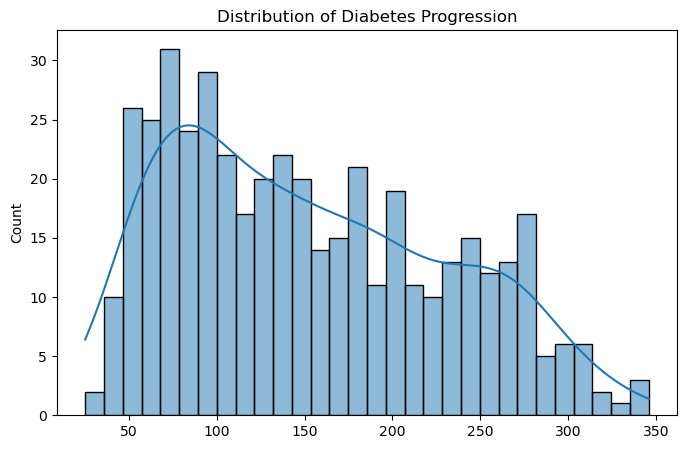

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True)
plt.title("Distribution of Diabetes Progression")
plt.show()

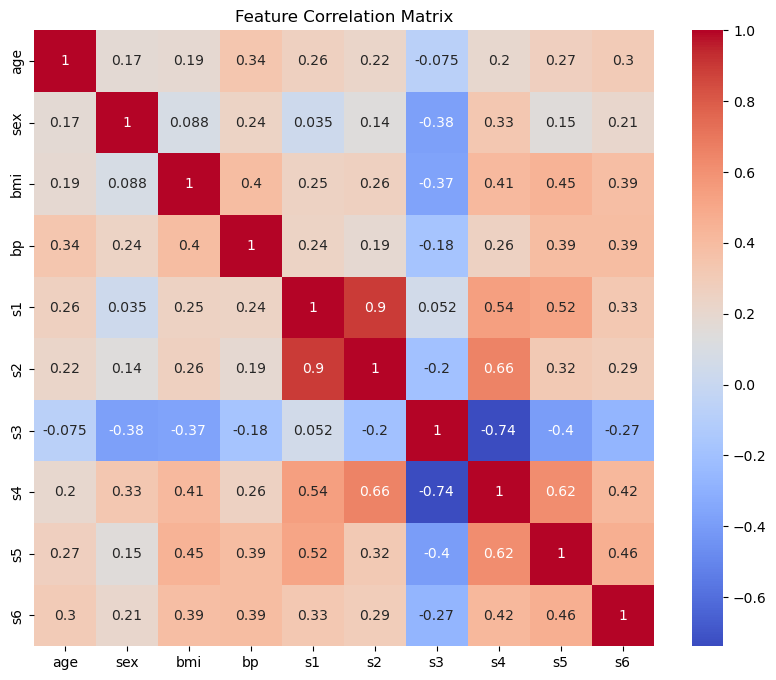

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

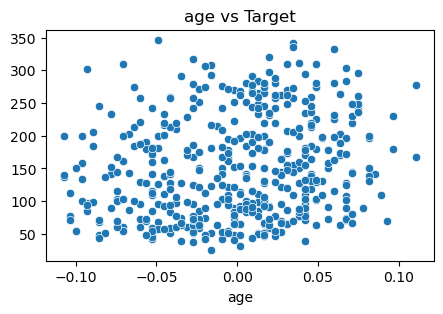

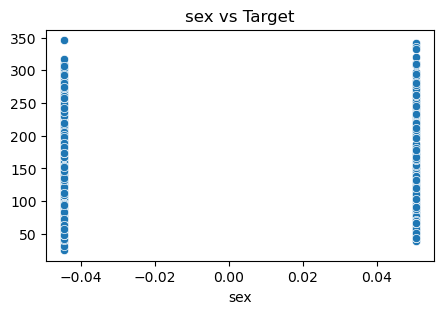

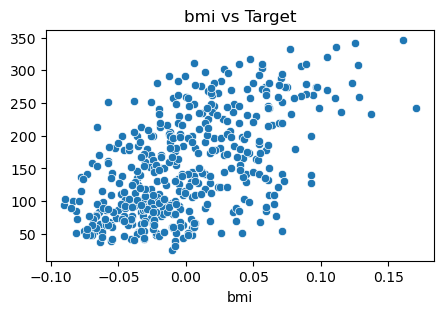

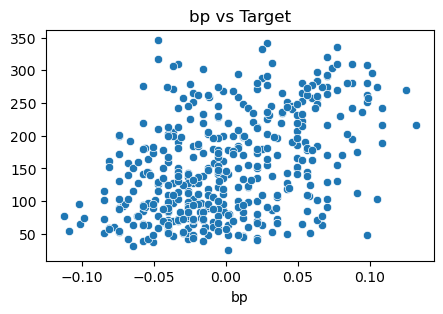

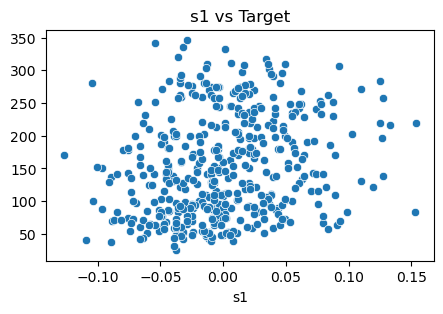

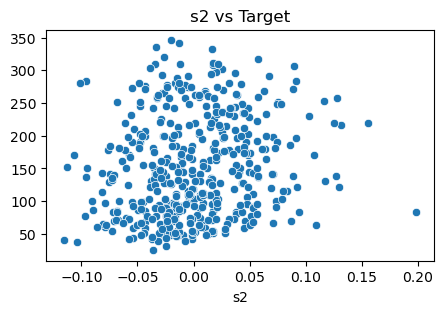

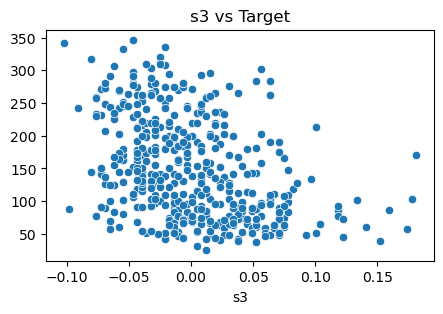

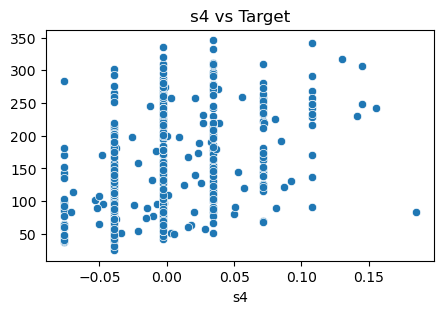

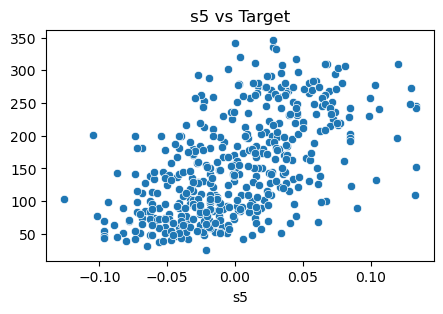

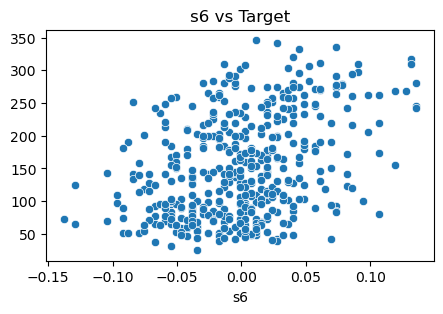

In [10]:
for feature in X.columns:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=X[feature], y=y)
    plt.title(f"{feature} vs Target")
    plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(353, 10) (89, 10)


In [12]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.summary()

E:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 31377.8438 - mae: 158.1365 - val_loss: 22187.0527 - val_mae: 132.9517
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 30975.9648 - mae: 156.8771 - val_loss: 21821.4922 - val_mae: 131.5951
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30427.3184 - mae: 155.1439 - val_loss: 21289.6133 - val_mae: 129.6210
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29559.5352 - mae: 152.4445 - val_loss: 20463.0430 - val_mae: 126.5598
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 28192.6309 - mae: 148.2140 - val_loss: 19249.8203 - val_mae: 122.0749
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26138.7656 - mae: 141.8892 - val_loss: 17639.4922 - val_mae: 115.9702
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 23462.1230 - mae: 133.2343 - val_loss: 15614.5283 - val_mae: 107.9733
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20107.4688 - mae: 121.8889 - val_l

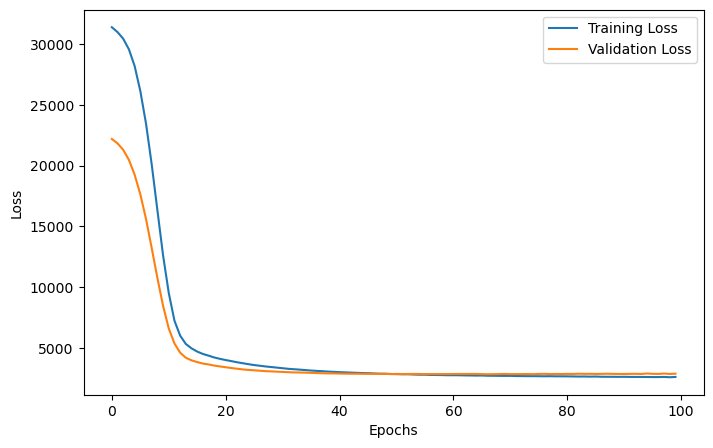

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [15]:
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Mean Squared Error: 2781.22241140528
R² Score: 0.4750579931607323


In [16]:
improved_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

improved_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

history2 = improved_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150


E:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 31333.4746 - mae: 158.0895 - val_loss: 22172.9297 - val_mae: 133.0168
Epoch 2/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30821.9824 - mae: 156.5965 - val_loss: 21647.9043 - val_mae: 131.1531
Epoch 3/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 29876.7559 - mae: 153.7534 - val_loss: 20710.7500 - val_mae: 127.7780
Epoch 4/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 28218.4570 - mae: 148.6641 - val_loss: 19129.8789 - val_mae: 121.9650
Epoch 5/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 25482.4238 - mae: 139.9009 - val_loss: 16624.3926 - val_mae: 112.2094
Epoch 6/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21235.2148 - mae: 125.3442 - val_loss: 13193.0713 - val_mae: 97.2587
Epoch 7/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15793.6670 - mae: 104.5529 - val_loss: 9233.5166 - val_mae: 76.6212
Epoch 8/150
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10298.2715 - mae: 80.0745 - val_loss: 5859.0176 - va

In [17]:
pred2 = improved_model.predict(X_test)

mse2 = mean_squared_error(y_test, pred2)
r22 = r2_score(y_test, pred2)

print("Improved MSE:", mse2)
print("Improved R²:", r22)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Improved MSE: 2713.310712648303
Improved R²: 0.4878759912061811


In [19]:
results = pd.DataFrame({
    "Model": ["Basic ANN", "Improved ANN"],
    "MSE": [mse, mse2],
    "R2 Score": [r2, r22]
})

results

,Model,MSE,R2 Score
0,Basic ANN,2781.222411,0.475058
1,Improved ANN,2713.310713,0.487876
